# Telco Customer Churn -- Metric Definition & Baselines

**Objective**: Define the evaluation framework (technical + business metrics) and train
baseline models that set the performance floor for all future experiments.

**Input**: `data/processed/telco_churn_clean.parquet` (exported by `01_eda.ipynb`)

**Baselines**:
1. `DummyClassifier` -- always predicts the majority class (performance floor)
2. `LogisticRegression` -- simple linear baseline with class-weight balancing

**Tracking**: All experiments logged to MLflow (local).

**Sections**:
1. Setup & data loading
2. Metric definitions (technical + business)
3. Preprocessing pipeline
4. Stratified split
5. Baseline training & evaluation
6. MLflow experiment tracking
7. Model comparison & conclusions

In [1]:
%%bash
pip3 install scikit-learn mlflow pyarrow matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)

/Users/joao.lage/miniforge3/lib/python3.12/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/Users/joao.lage/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Cleaned Data

In [3]:
DATA_PROCESSED = Path("..") / "data" / "processed"
if not (Path("..") / "data").exists():
    DATA_PROCESSED = Path("data") / "processed"

df = pd.read_parquet(DATA_PROCESSED / "telco_churn_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

EDA_ONLY_COLS = ["city", "latitude", "longitude"]
TARGET = "churn"

feature_cols = [c for c in df.columns if c not in EDA_ONLY_COLS + [TARGET]]
num_cols = [c for c in feature_cols if df[c].dtype in ["float64", "int64"]]
cat_cols = [c for c in feature_cols if df[c].dtype == "object"]

print(f"\nFeatures for modeling: {len(feature_cols)}")
print(f"  Numeric ({len(num_cols)}): {num_cols}")
print(f"  Categorical ({len(cat_cols)}): {cat_cols}")
print(f"  EDA-only (dropped): {EDA_ONLY_COLS}")
print(f"\nTarget distribution:")
print(df[TARGET].value_counts())
print(f"Churn rate: {df[TARGET].mean():.2%}")

Loaded: 7,043 rows x 23 columns

Features for modeling: 19
  Numeric (3): ['tenure_months', 'monthly_charges', 'total_charges']
  Categorical (16): ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']
  EDA-only (dropped): ['city', 'latitude', 'longitude']

Target distribution:
churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54%


## 2. Metric Definitions

The Tech Challenge requires both **technical metrics** and a **business metric**.
This section explains each one and why it matters for our churn problem.

### 2.1 Technical Metrics

#### AUC-ROC (Area Under the ROC Curve)

The ROC curve plots **True Positive Rate** (recall) vs **False Positive Rate** across
every possible classification threshold.

- Range: 0.5 (random) to 1.0 (perfect)
- **Threshold-agnostic**: evaluates the model's ability to *rank* churners above non-churners,
  regardless of the decision cutoff
- **Caveat for imbalanced data**: because it includes True Negatives in the FPR denominator,
  AUC-ROC can look optimistic when the negative class dominates (73% in our case).
  A model that catches most churners but also flags many non-churners can still score well.

#### PR-AUC (Area Under the Precision-Recall Curve)

The PR curve plots **Precision** vs **Recall**, focusing entirely on the positive class (churners).

- Range: baseline = prevalence (0.265 for us) to 1.0 (perfect)
- **Better for imbalanced data**: ignores True Negatives entirely.
  It answers: *"Of those I flagged as churn, how many actually churned?"* (Precision)
  and *"Of all real churners, how many did I catch?"* (Recall)
- A model with high PR-AUC is genuinely good at finding churners without
  drowning the retention team in false alerts.

#### F1-Score

The harmonic mean of Precision and Recall **at a specific threshold** (default = 0.5).

- Range: 0 to 1
- Useful as a single-number summary, but **depends on the chosen threshold**.
  AUC-ROC and PR-AUC are threshold-agnostic; F1 is not.
- We report F1 at the default threshold for comparability, but the curves
  above tell a richer story.

### 2.2 Business Metric: Cost of Churn Avoided

Technical metrics measure statistical performance. The business needs to know:
**"How much money does this model save?"**

We define a **per-customer** cost matrix based on the model's decisions:

| Prediction \ Reality | Actually Churned | Did Not Churn |
|---|---|---|
| **Predicted Churn** | TP: retention offer sent, customer saved. Cost = $50 offer. Revenue preserved. | FP: unnecessary retention offer. Cost = $50 wasted. |
| **Predicted No Churn** | FN: customer leaves unnoticed. **Lost = customer's `monthly_charges` x 12 months.** | TN: no action needed. Cost = $0. |

**Why per-customer instead of a fixed FN cost?**

Our dataset contains each customer's real `monthly_charges` ($18 -- $119).
Instead of using a single average ($780 for everyone), we use the **actual monthly charge
of each missed churner** multiplied by a 12-month revenue horizon. This means:
- Losing a $119/month customer costs $1,425 (the model is penalized more)
- Losing an $18/month customer costs $219 (still bad, but less impactful)

Assumptions:
- **Retention offer cost** (`COST_RETENTION`): $50 per customer (discount/incentive)
- **Revenue loss horizon** (`HORIZON_MONTHS`): 12 months
- **FN cost per customer**: `monthly_charges * 12` (range: $219 -- $1,425; mean ~$769)

The cost asymmetry remains large: on average, losing a customer costs **~15x** more
than sending an unnecessary offer. This justifies models that favor recall over precision.

Total business cost = `sum(FP) * $50 + sum(monthly_charges[FN] * 12)`

The model that **minimizes this total cost** is the best from a business perspective,
even if its F1 or AUC-ROC isn't the absolute highest.

In [4]:
COST_RETENTION = 50
HORIZON_MONTHS = 12


def business_cost(y_true, y_pred, monthly_charges):
    """Per-customer business cost using actual monthly charges for FN."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mc = np.array(monthly_charges)

    is_fp = (y_pred == 1) & (y_true == 0)
    is_fn = (y_pred == 0) & (y_true == 1)

    fp_total = int(is_fp.sum()) * COST_RETENTION
    fn_total = float((mc[is_fn] * HORIZON_MONTHS).sum())
    return fp_total + fn_total


def evaluate_model(name, y_true, y_pred, monthly_charges, y_prob=None):
    """Compute all metrics for a model and return as a dict."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    mc = np.array(monthly_charges)
    fn_mask = (y_pred_arr == 0) & (y_true_arr == 1)
    fn_charges = mc[fn_mask]

    metrics = {
        "model": name,
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "business_cost": business_cost(y_true, y_pred, monthly_charges),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "fn_cost_mean": float(fn_charges.mean()) * HORIZON_MONTHS if len(fn_charges) > 0 else 0.0,
        "fn_cost_median": float(np.median(fn_charges)) * HORIZON_MONTHS if len(fn_charges) > 0 else 0.0,
    }
    return metrics


mc_all = df["monthly_charges"]
print(f"Cost assumptions (per-customer):")
print(f"  Retention offer (FP):  ${COST_RETENTION} fixed")
print(f"  Revenue loss (FN):     monthly_charges x {HORIZON_MONTHS} months")
print(f"    Range:  ${mc_all.min() * HORIZON_MONTHS:,.0f} -- ${mc_all.max() * HORIZON_MONTHS:,.0f}")
print(f"    Mean:   ${mc_all.mean() * HORIZON_MONTHS:,.0f}")
print(f"    Median: ${mc_all.median() * HORIZON_MONTHS:,.0f}")
print(f"  Avg cost ratio FN/FP:  {mc_all.mean() * HORIZON_MONTHS / COST_RETENTION:.0f}x")

Cost assumptions (per-customer):
  Retention offer (FP):  $50 fixed
  Revenue loss (FN):     monthly_charges x 12 months
    Range:  $219 -- $1,425
    Mean:   $777
    Median: $844
  Avg cost ratio FN/FP:  16x


## 3. Preprocessing Pipeline

We use a scikit-learn `ColumnTransformer` to handle numeric and categorical features
in a single reproducible pipeline:
- **Numeric**: `StandardScaler` (zero mean, unit variance)
- **Categorical**: `OneHotEncoder` with `drop="first"` to avoid multicollinearity

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

print("Preprocessor ready.")
print(f"  Numeric ({len(num_cols)}):     StandardScaler -> {num_cols}")
print(f"  Categorical ({len(cat_cols)}): OneHotEncoder  -> {cat_cols}")

Preprocessor ready.
  Numeric (3):     StandardScaler -> ['tenure_months', 'monthly_charges', 'total_charges']
  Categorical (16): OneHotEncoder  -> ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


## 4. Stratified Train/Test Split

80/20 split, stratified on the target to preserve the 73/27 class ratio in both sets.

In [6]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

mc_test = X_test["monthly_charges"].values

print(f"Train: {X_train.shape[0]:,} rows  |  Churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:,} rows  |  Churn rate: {y_test.mean():.2%}")
print(f"\nTest set monthly_charges: ${mc_test.min():.0f} -- ${mc_test.max():.0f} (median ${np.median(mc_test):.0f})")

Train: 5,634 rows  |  Churn rate: 26.54%
Test:  1,409 rows  |  Churn rate: 26.54%

Test set monthly_charges: $18 -- $117 (median $70)


## 5. Baseline Models

### 5.1 DummyClassifier (Performance Floor)

Always predicts the majority class (no churn). This is the absolute minimum
any real model must beat. It sets the baseline for accuracy (~73.5%),
but will have **zero recall** for churners -- it never catches anyone.

In [7]:
pipe_dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=SEED)),
])

pipe_dummy.fit(X_train, y_train)
y_pred_dummy = pipe_dummy.predict(X_test)

try:
    y_prob_dummy = pipe_dummy.predict_proba(X_test)[:, 1]
except Exception:
    y_prob_dummy = None

metrics_dummy = evaluate_model("DummyClassifier", y_test, y_pred_dummy, mc_test, y_prob_dummy)

print("DummyClassifier (always predicts majority class)")
print("=" * 50)
print(classification_report(y_test, y_pred_dummy, target_names=["No Churn", "Churn"]))
print(f"Business cost: ${metrics_dummy['business_cost']:,.0f}")

DummyClassifier (always predicts majority class)
              precision    recall  f1-score   support

    No Churn       0.73      1.00      0.85      1035
       Churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

Business cost: $326,579


/Users/joao.lage/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/joao.lage/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/joao.lage/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

### 5.2 Logistic Regression (Linear Baseline)

A simple linear model with `class_weight="balanced"` to compensate for
the 2.8:1 class imbalance. This automatically upweights the minority class
(churners) in the loss function, improving recall at the expense of some precision.

In [8]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED,
        solver="lbfgs",
    )),
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]

metrics_lr = evaluate_model("LogisticRegression", y_test, y_pred_lr, mc_test, y_prob_lr)

print("LogisticRegression (class_weight='balanced')")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC:       {metrics_lr['roc_auc']:.4f}")
print(f"PR-AUC:        {metrics_lr['pr_auc']:.4f}")
print(f"F1 (Churn):    {metrics_lr['f1']:.4f}")
print(f"Business cost: ${metrics_lr['business_cost']:,.0f}")

LogisticRegression (class_weight='balanced')
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC:       0.8489
PR-AUC:        0.6452
F1 (Churn):    0.6178
Business cost: $75,929


## 6. MLflow Experiment Tracking

Register both experiments with parameters, metrics, dataset info, and serialized models.

In [9]:
MLFLOW_TRACKING_URI = "mlruns"
EXPERIMENT_NAME = "Telco-Churn-Baselines"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)


def log_experiment(pipe, metrics, params):
    """Log a single experiment run to MLflow."""
    with mlflow.start_run(run_name=metrics["model"]):
        mlflow.log_params(params)

        mlflow.log_metric("f1", metrics["f1"])
        mlflow.log_metric("precision", metrics["precision"])
        mlflow.log_metric("recall", metrics["recall"])
        if not np.isnan(metrics["roc_auc"]):
            mlflow.log_metric("roc_auc", metrics["roc_auc"])
        if not np.isnan(metrics["pr_auc"]):
            mlflow.log_metric("pr_auc", metrics["pr_auc"])
        mlflow.log_metric("business_cost", metrics["business_cost"])
        mlflow.log_metric("tp", metrics["tp"])
        mlflow.log_metric("fp", metrics["fp"])
        mlflow.log_metric("fn", metrics["fn"])
        mlflow.log_metric("tn", metrics["tn"])

        mlflow.log_param("dataset_version", "telco_churn_clean.parquet")
        mlflow.log_param("train_size", X_train.shape[0])
        mlflow.log_param("test_size", X_test.shape[0])
        mlflow.log_param("seed", SEED)
        mlflow.log_param("n_features", len(feature_cols))
        mlflow.log_param("cost_retention", COST_RETENTION)
        mlflow.log_param("cost_horizon_months", HORIZON_MONTHS)
        mlflow.log_param("cost_type", "per_customer_monthly_charges")

        mlflow.sklearn.log_model(pipe, artifact_path="model")

    print(f"  Logged: {metrics['model']}")


print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Experiment: {EXPERIMENT_NAME}")
print()

log_experiment(pipe_dummy, metrics_dummy, {
    "model_type": "DummyClassifier",
    "strategy": "most_frequent",
})

log_experiment(pipe_lr, metrics_lr, {
    "model_type": "LogisticRegression",
    "class_weight": "balanced",
    "solver": "lbfgs",
    "max_iter": 1000,
})

print("\nAll experiments logged.")

/Users/joao.lage/miniforge3/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/17 17:30:48 INFO mlflow.tracking.fluent: Experiment with name 'Telco-Churn-Baselines' does not exist. Creating a new experiment.


MLflow tracking URI: mlruns
Experiment: Telco-Churn-Baselines



2026/04/17 17:30:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 17:30:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/17 17:30:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 17:30:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  Logged: DummyClassifier
  Logged: LogisticRegression

All experiments logged.


## 7. Model Comparison

### 7.1 Metrics Table

In [10]:
results = pd.DataFrame([metrics_dummy, metrics_lr]).set_index("model")

display_cols = ["f1", "precision", "recall", "roc_auc", "pr_auc", "business_cost"]
print("MODEL COMPARISON")
print("=" * 70)
results[display_cols].round(4)

MODEL COMPARISON


,f1,precision,recall,roc_auc,pr_auc,business_cost
model,,,,,,
DummyClassifier,0.0000,0.0000,0.0000,0.5000,0.2654,326578.8
LogisticRegression,0.6178,0.5123,0.7781,0.8489,0.6452,75929.0


### 7.2 ROC and Precision-Recall Curves

Side-by-side comparison of both threshold-agnostic metrics.
The DummyClassifier produces a single point (no curve) since it has no probability calibration.

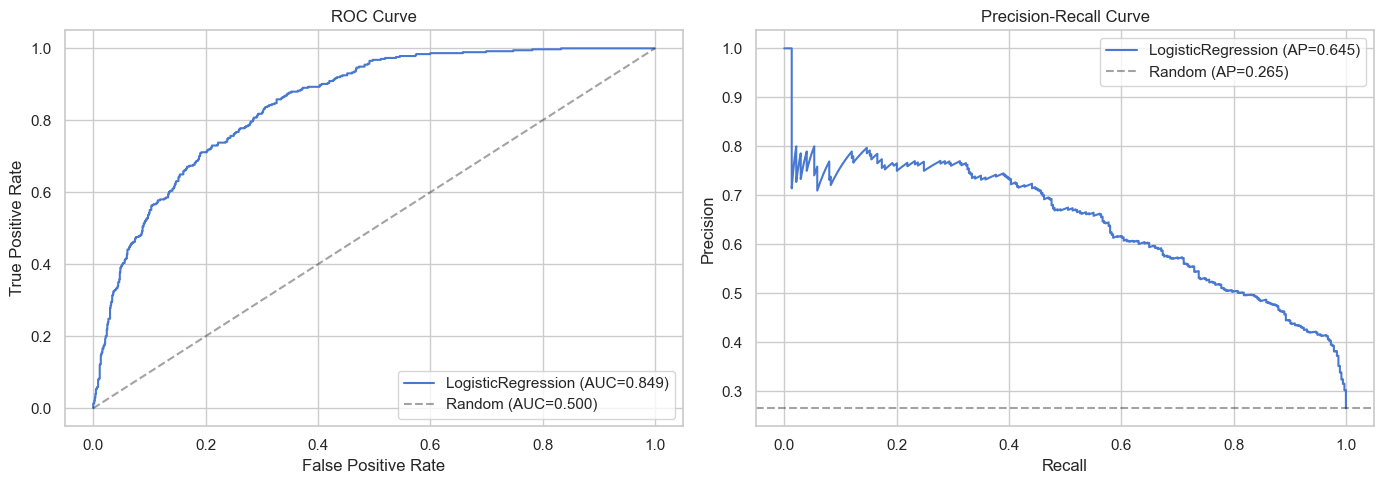

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
ax = axes[0]
if y_prob_lr is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
    ax.plot(fpr, tpr, label=f"LogisticRegression (AUC={metrics_lr['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")

# --- PR Curve ---
ax = axes[1]
if y_prob_lr is not None:
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob_lr)
    ax.plot(rec_vals, prec_vals, label=f"LogisticRegression (AP={metrics_lr['pr_auc']:.3f})")
baseline_pr = y_test.mean()
ax.axhline(y=baseline_pr, color="k", linestyle="--", alpha=0.4, label=f"Random (AP={baseline_pr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 7.3 Business Cost Analysis

Compare the financial impact of each model's predictions.

In [12]:
print("BUSINESS COST BREAKDOWN (per-customer monthly_charges x 12)")
print("=" * 75)

for m in [metrics_dummy, metrics_lr]:
    name = m["model"]
    fp_cost = m["fp"] * COST_RETENTION
    fn_cost = m["business_cost"] - fp_cost
    print(f"\n{name}:")
    print(f"  True Positives  (churners caught):     {m['tp']:>5}")
    print(f"  False Positives (unnecessary offers):   {m['fp']:>5}  x ${COST_RETENTION:>3} = ${fp_cost:>10,.0f}")
    print(f"  False Negatives (missed churners):      {m['fn']:>5}  (avg ${m['fn_cost_mean']:,.0f}/customer)")
    print(f"    -> FN total cost (sum of mc*12):                    ${fn_cost:>10,.0f}")
    print(f"  True Negatives  (correct no-action):   {m['tn']:>5}")
    print(f"  -----------------------------------------------")
    print(f"  TOTAL BUSINESS COST:                           ${m['business_cost']:>10,.0f}")

saving = metrics_dummy["business_cost"] - metrics_lr["business_cost"]
print(f"\nLogisticRegression saves ${saving:,.0f} vs DummyClassifier")
print(f"  ({saving / metrics_dummy['business_cost']:.1%} cost reduction)")

BUSINESS COST BREAKDOWN (per-customer monthly_charges x 12)

DummyClassifier:
  True Positives  (churners caught):         0
  False Positives (unnecessary offers):       0  x $ 50 = $         0
  False Negatives (missed churners):        374  (avg $873/customer)
    -> FN total cost (sum of mc*12):                    $   326,579
  True Negatives  (correct no-action):    1035
  -----------------------------------------------
  TOTAL BUSINESS COST:                           $   326,579

LogisticRegression:
  True Positives  (churners caught):       291
  False Positives (unnecessary offers):     277  x $ 50 = $    13,850
  False Negatives (missed churners):         83  (avg $748/customer)
    -> FN total cost (sum of mc*12):                    $    62,079
  True Negatives  (correct no-action):     758
  -----------------------------------------------
  TOTAL BUSINESS COST:                           $    75,929

LogisticRegression saves $250,650 vs DummyClassifier
  (76.8% cost reduction

### 7.4 Confusion Matrices

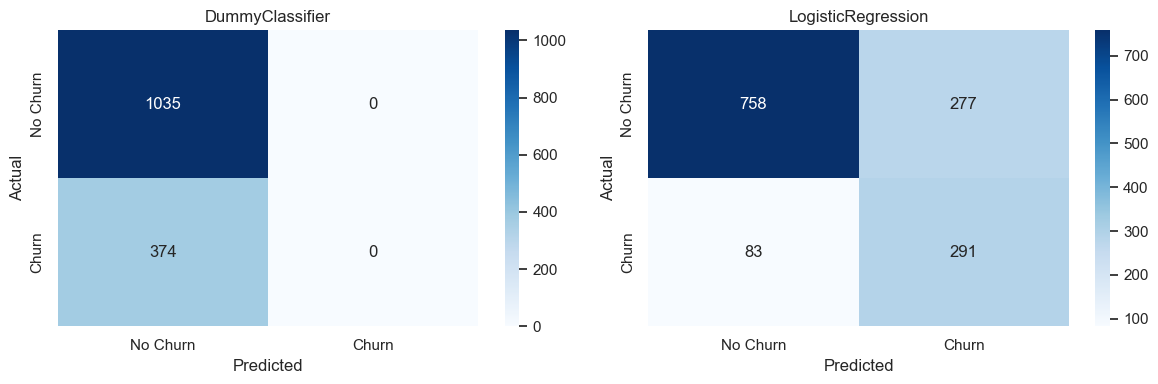

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [("DummyClassifier", y_pred_dummy), ("LogisticRegression", y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Conclusions

**Key takeaways from the baselines:**

1. **DummyClassifier** achieves ~73% accuracy by always predicting "no churn", but has
   **zero recall** -- it never catches a single churner. Its business cost is maximum
   because every churner is a False Negative.

2. **LogisticRegression** with `class_weight="balanced"` trades some accuracy for
   **meaningful recall** -- it actually identifies churners. The business cost drops
   significantly because catching churners early ($50 retention offer) is far cheaper
   than losing their monthly revenue for a year.

3. **Per-customer cost matters**: using each customer's real `monthly_charges * 12`
   instead of a fixed scalar means the model is penalized more for missing high-value
   churners (~$1,400 loss for a $119/month customer vs ~$219 for a $18/month customer).
   We tested both approaches (fixed value and CLTV from the original dataset) and chose
   `monthly_charges * 12` because it is grounded in real per-customer data, transparent
   in its assumption (1 year of revenue), and already present in our cleaned dataset.

4. **PR-AUC is more informative than AUC-ROC** for this problem due to the class imbalance.

**Next steps (Etapa 2):**
- Build an MLP with PyTorch and compare against these baselines
- Tune the classification threshold using the cost function
- Experiment with SMOTE and other imbalance strategies
- All tracked in MLflow for reproducibility